<a href="https://colab.research.google.com/github/DivyanshSingh09/DNQ-DroneDeliveryAgent/blob/main/DQN_DroneDeliveryAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

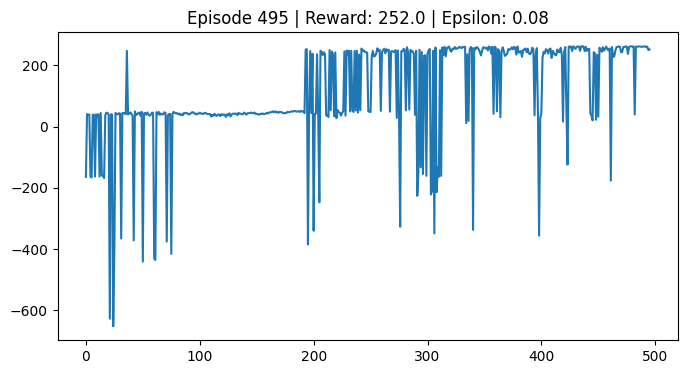

Training Complete!


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
from gymnasium import spaces
import pygame
import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- 1. HEADLESS ENVIRONMENT SETUP ---
os.environ["SDL_VIDEODRIVER"] = "dummy"

class DroneDeliveryEnv(gym.Env):
    metadata = {"render_modes": ["rgb_array"], "render_fps": 10}

    def __init__(self, grid_size=20):
        super(DroneDeliveryEnv, self).__init__()
        self.grid_size = grid_size
        self.window_size = 512
        self.num_packages = 2

        self.observation_space = spaces.Dict({
            "agent": spaces.Box(0, grid_size - 1, shape=(2,), dtype=int),
            "packages": spaces.MultiBinary(self.num_packages),
        })
        self.action_space = spaces.Discrete(5)
        self._action_to_direction = {
            0: np.array([1, 0]), 1: np.array([-1, 0]),
            2: np.array([0, 1]), 3: np.array([0, -1]), 4: np.array([0, 0]),
        }
        self._package_locations = [np.array([3, 3]), np.array([15, 15])]
        self._depot_location = np.array([0, 0])
        self._obstacle_location = np.array([10, 10])

    def _get_obs(self):
        return {"agent": self._agent_location.copy(), "packages": self._packages_status.copy()}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self._agent_location = self._depot_location.copy()
        self._packages_status = np.ones(self.num_packages, dtype=int)
        return self._get_obs(), {}

    def step(self, action):
        target = self._depot_location if np.all(self._packages_status == 0) else \
                 self._package_locations[0] if self._packages_status[0] == 1 else self._package_locations[1]

        dist_before = np.linalg.norm(self._agent_location - target)
        self._agent_location = np.clip(self._agent_location + self._action_to_direction[action], 0, self.grid_size - 1)
        dist_after = np.linalg.norm(self._agent_location - target)

        reward, terminated = -1, False
        if dist_after < dist_before: reward += 0.5

        if np.array_equal(self._agent_location, self._obstacle_location):
            reward, terminated = -500, True
        else:
            for i in range(self.num_packages):
                if self._packages_status[i] == 1 and np.array_equal(self._agent_location, self._package_locations[i]):
                    self._packages_status[i], reward = 0, 200

        if np.all(self._packages_status == 0) and np.array_equal(self._agent_location, self._depot_location):
            reward, terminated = 1000, True

        return self._get_obs(), reward, terminated, False, {}

# --- 2. AI AGENT (DQN) ---
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, action_dim)
        )
    def forward(self, x): return self.net(x)

class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.policy_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.memory = []
        self.batch_size = 64
        self.gamma = 0.95

    def _flatten(self, obs):
        return np.concatenate([obs['agent'], obs['packages']]).astype(np.float32)

    def choose_action(self, obs, epsilon):
        if random.random() < epsilon: return random.randint(0, 4)
        state = torch.FloatTensor(self._flatten(obs)).unsqueeze(0).to(self.device)
        return self.policy_net(state).argmax().item()

    def learn(self):
        if len(self.memory) < self.batch_size: return
        batch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = map(np.stack, zip(*batch))

        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        q_v = self.policy_net(states).gather(1, actions)
        next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
        targets = rewards + (self.gamma * next_q * (1 - dones))

        loss = F.mse_loss(q_v, targets)
        self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()

# --- UPDATED FASTER TRAINING LOOP ---
env = DroneDeliveryEnv()
agent = DQNAgent(state_dim=4, action_dim=5)
episodes, scores = 500, []
epsilon = 1.0
max_steps_per_episode = 200 # Prevent infinite wandering

for ep in range(episodes):
    obs, _ = env.reset()
    score, done = 0, False

    for step in range(max_steps_per_episode): # Added step limit
        action = agent.choose_action(obs, epsilon)
        next_obs, reward, done, truncated, _ = env.step(action) # 'truncated' added

        agent.memory.append((agent._flatten(obs), action, reward, agent._flatten(next_obs), done))
        if len(agent.memory) > 10000: agent.memory.pop(0)

        agent.learn()
        obs = next_obs
        score += reward

        if done: break # Stop if we hit target/obstacle

    scores.append(score)
    epsilon = max(0.01, epsilon * 0.995)

    if ep % 10 == 0:
        agent.target_net.load_state_dict(agent.policy_net.state_dict())

    if ep % 5 == 0: # Update graph more frequently to see life
        clear_output(wait=True)
        plt.figure(figsize=(8,4))
        plt.plot(scores)
        plt.title(f"Episode {ep} | Reward: {score:.1f} | Epsilon: {epsilon:.2f}")
        plt.show()

print("Training Complete!")